In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# 07 — Does the assembled decoder learn?

A connected gradient is necessary but not sufficient evidence of learning. Here we test one bounded claim: can the tiny decoder memorize a consistent next-token batch?

**Pre-run contract:** seed 505; CPU float32; 2 sequences of length 7 shifted into [2,6]; vocabulary 16; width 16; two blocks; 4 heads of width 4; hidden width 32; 160 full-batch AdamW steps, learning rate .02, weight decay 0; no dropout, clipping, scheduler, or early stopping. Success: all losses/gradients finite, final CE < .05, training-token accuracy 100%. Do not change the seed or budget merely to hide a failure.

Specification: ../../experiments/specs/2026-09-06-decoder-notebooks.md.

## How to work through this notebook

Run setup once. At each checkpoint, write a prediction and try the small implementation before reading its adjacent reference solution. All reference cells run unchanged from top to bottom; exercise cells contain safe, optional starting points. Numerical checks use CPU float64 unless explicitly noted. Agent-verified reference execution is separate from your learning progress.

In [2]:
from pathlib import Path
import sys, copy, math, inspect
from dataclasses import replace
import torch
from torch import nn
from torch.nn import functional as F
root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/dongxi_llms/decoder_lab.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook from inside the Dongxi_LLMs repository")
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
from dongxi_llms.decoder_lab import (
    DecoderConfig, TinyDecoder, DecoderBlock, MultiHeadAttention, MLP, RMSNorm,
    layer_norm, rms_norm, rope, attend, parameter_count, analytical_parameters,
    cost_estimate, teaching_batch, next_token_loss, fit_one_batch)
torch.set_num_threads(1)
torch.manual_seed(505)
DTYPE = torch.float64
def close(actual, expected, atol=1e-10, rtol=1e-8):
    torch.testing.assert_close(actual, expected, atol=atol, rtol=rtol)
print("CPU reference environment:", torch.__version__)


CPU reference environment: 2.14.1+cpu


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from dongxi_llms import decoder_visuals as viz
def show_visual(figure):
    display(figure)
    plt.close(figure)


## Architecture map — your location in the model

The highlighted stage is this lesson’s focus. B = batch, T = positions, D = model width, V = vocabulary size. This is a structural map, not measured activations or runtime. The baseline route adds learned position embeddings before the blocks.

![Architecture map — your location in the model. The highlighted stage is this lesson’s focus. B = batch, T = positions, D = model width, V = vocabulary size. This is a structural map, not measured activations or runtime. The baseline route adds learned position embeddings before the blocks.](../figures/chapter-05/day-05-07_one_batch_learning-architecture-map.png)

*Saved architecture schematic. The following cell regenerates it; it does not execute or train a model.*

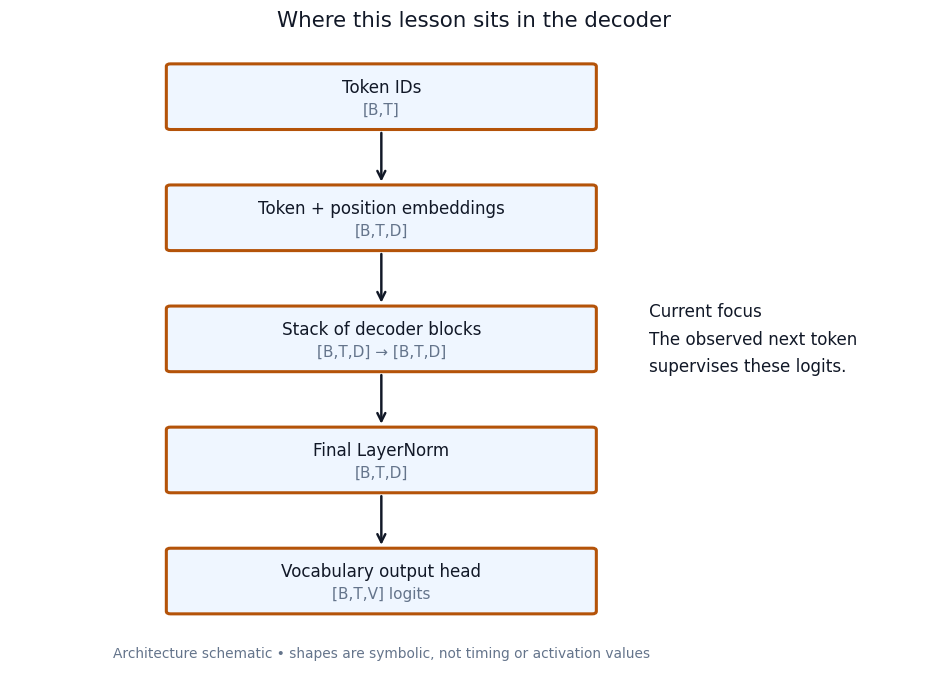

In [4]:
from dongxi_llms import decoder_architecture as architecture
show_visual(architecture.model_map(focus='training', modern=False))

## Connect architecture to loss and optimizer updates

The model produces logits. Observed next-token labels supervise those logits; backward computes gradients, and the optimizer updates parameters for the next forward pass. No softmax sampling is required to calculate the training loss.

![Connect architecture to loss and optimizer updates. The model produces logits. Observed next-token labels supervise those logits; backward computes gradients, and the optimizer updates parameters for the next forward pass. No softmax sampling is required to calculate the training loss.](../figures/chapter-05/day-05-07_one_batch_learning-architecture-detail.png)

*Saved architecture schematic. The following cell regenerates it; it does not execute or train a model.*

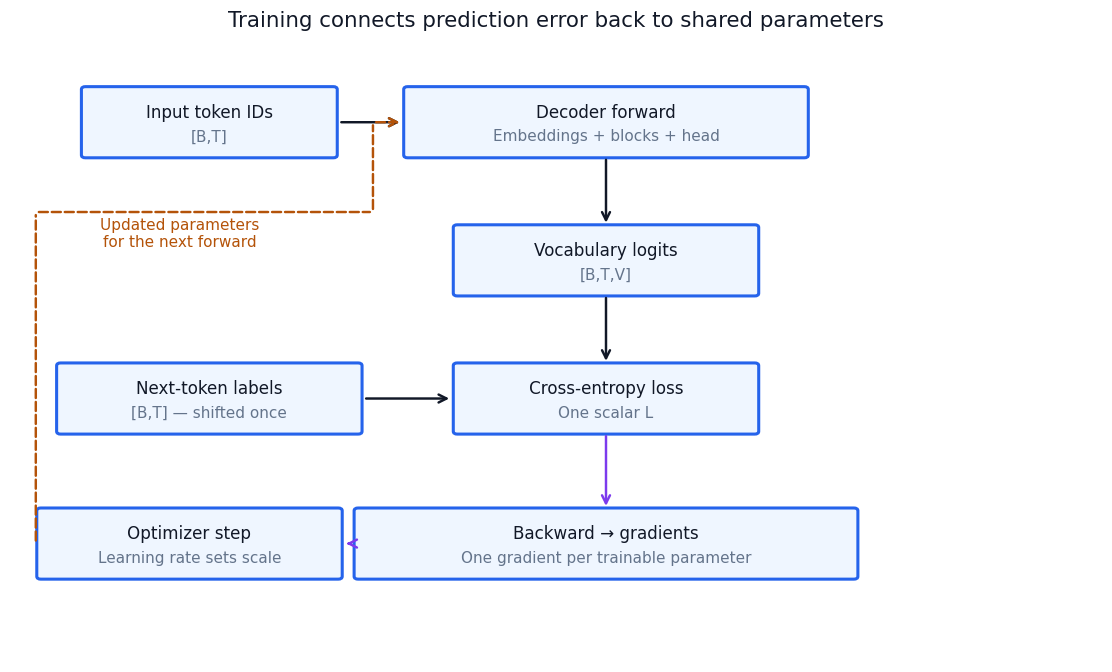

In [5]:
show_visual(architecture.training_detail())

## 1. Audit the batch and training loop

Inspect the exact input/label pairs. What does a low loss on these pairs establish, and what remains untested? Read the small reusable training loop before running it.

**Your prediction:** _Write it here before running the reference._

In [6]:
ids, labels = teaching_batch()
# Record your prediction here before training.

### Reference solution

Run after your attempt; compare the mechanism, not just the final numbers.

In [7]:
sequence = torch.tensor([[1,2,3,4,5,6,7], [8,9,10,11,12,13,14]])
assert torch.equal(ids, sequence[:, :-1])
assert torch.equal(labels, sequence[:, 1:])
print("Input IDs:", ids)
print("Next-token labels:", labels)
print(inspect.getsource(fit_one_batch))

Input IDs: tensor([[ 1,  2,  3,  4,  5,  6],
        [ 8,  9, 10, 11, 12, 13]])
Next-token labels: tensor([[ 2,  3,  4,  5,  6,  7],
        [ 9, 10, 11, 12, 13, 14]])
def fit_one_batch(steps=160, seed=505, lr=.02):
    """Bounded CPU float32 learning experiment; fixed budget, no best-seed search."""
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(seed)
        model = TinyDecoder()
        ids, labels = teaching_batch()
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.)
        initial = float(next_token_loss(model(ids), labels).detach())
        history = []
        for step in range(steps):
            optimizer.zero_grad(set_to_none=True)
            loss = next_token_loss(model(ids), labels)
            if not torch.isfinite(loss):
                raise RuntimeError('Nonfinite loss')
            loss.backward()
            if not all(p.grad is None or torch.isfinite(p.grad).all() for p in model.parameters()):
                rai

### Why this works

The labels are shifted exactly once and contain no conflicting next token for an identical prefix. Fitting them tests this implementation and optimization setup; it does not estimate language capability.

## 2. Run the declared learning experiment

Use the reference loop, or write your own matching the exact contract. Compare initial and final loss, inspect parameters, and do not stop at the first promising checkpoint.

**Your prediction:** _Write it here before running the reference._

In [8]:
# Your implementation may go here; the adjacent reference runs the full contract.

### Reference solution

Run after your attempt; compare the mechanism, not just the final numbers.

In [9]:
torch.manual_seed(505)
frozen = TinyDecoder().eval()
frozen_loss_before = float(next_token_loss(frozen(ids), labels).detach())
trained, result = fit_one_batch()
close(torch.tensor(result["initial_loss"]), torch.tensor(frozen_loss_before), atol=1e-6)
assert result["final_loss"] < .05 and result["accuracy"] == 1.
assert all(math.isfinite(value) for value in result["history"])
print({k: v for k, v in result.items() if k != "history"})
print("Loss samples:", [(i+1, result["history"][i]) for i in (0, 9, 39, 79, 159)])
print("Trained token predictions:", trained(ids).argmax(-1))
print("Embedding change norm:", float((trained.token.weight-frozen.token.weight).norm().detach()))

{'seed': 505, 'steps': 160, 'lr': 0.02, 'initial_loss': 2.774792432785034, 'final_loss': 0.0007856183219701052, 'accuracy': 1.0}
Loss samples: [(1, 2.774792432785034), (10, 1.1427533626556396), (40, 0.00972698163241148), (80, 0.0016963970847427845), (160, 0.0007916134782135487)]
Trained token predictions: tensor([[ 2,  3,  4,  5,  6,  7],
        [ 9, 10, 11, 12, 13, 14]])
Embedding change norm: 6.10724401473999


### Why this works

Each iteration computes logits, loss, gradients, and then an optimizer update. The final reported loss is evaluated after the last update; history entries are measured before each update. Success demonstrates one-batch learning, not generalization.

### Visual explanation — See loss reduction become next-token prediction

The curve includes the post-update final loss. Probability panels show the first training sequence before and after fitting; crosses mark its labels. This is memorization evidence, not an independent evaluation.

The figure uses this lesson’s tensors. Rerun it after changing the preceding experiment.

![See loss reduction become next-token prediction. The curve includes the post-update final loss. Probability panels show the first training sequence before and after fitting; crosses mark its labels. This is memorization evidence, not an independent evaluation.](../figures/chapter-05/day-05-07_one_batch_learning-visual-learning.png)

*Saved reference preview. The code below regenerates this figure from the current lesson state; it does not overwrite the preview.*

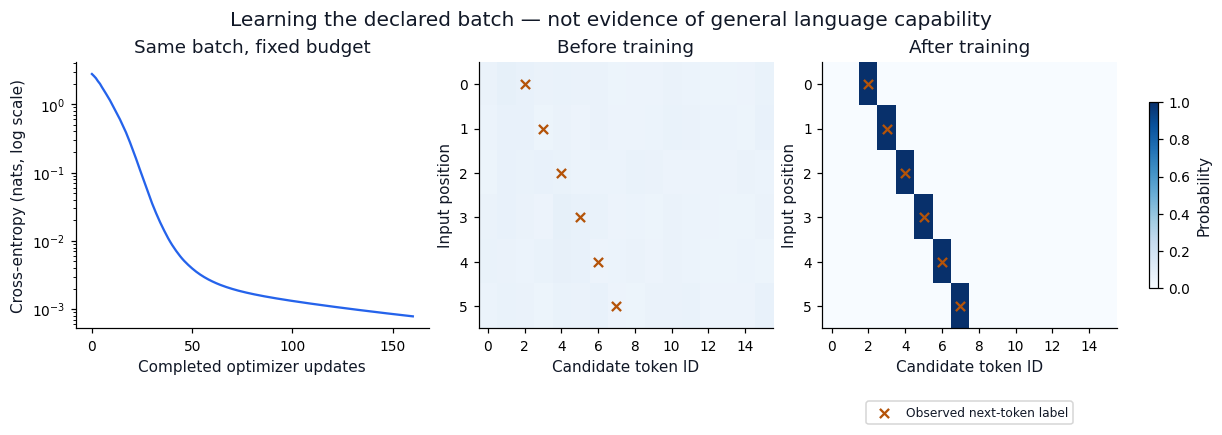

In [10]:
show_visual(viz.learning(result['history'], result['final_loss'], frozen(ids)[0], trained(ids)[0], labels[0]))

## 3. Freeze the control and test changed contexts

Keep the initial model unchanged. Change the order of the input tokens and inspect the trained model's predictions. Can the training accuracy tell us whether these new predictions are good?

**Your prediction:** _Write it here before running the reference._

In [11]:
# Predict the evidence boundary before inspecting the changed-context outputs.

### Reference solution

Run after your attempt; compare the mechanism, not just the final numbers.

In [12]:
frozen_loss_after = float(next_token_loss(frozen(ids), labels).detach())
assert frozen_loss_after == frozen_loss_before
changed = ids.flip(1)
with torch.no_grad():
    print("Changed input IDs:", changed)
    print("Changed-context predictions:", trained(changed).argmax(-1))
    print("Original-context predictions:", trained(ids).argmax(-1))
    prompt = ids[:1, :1].clone()
    for _ in range(6):
        next_id = trained(prompt)[:, -1].argmax(-1, keepdim=True)
        prompt = torch.cat((prompt, next_id), dim=1)
    print("Greedy rollout from the first training prefix:", prompt)
print("Frozen control loss stayed at:", frozen_loss_after)

Changed input IDs: tensor([[ 6,  5,  4,  3,  2,  1],
        [13, 12, 11, 10,  9,  8]])
Changed-context predictions: tensor([[ 6,  6,  5,  6,  3,  7],
        [ 9, 13, 12, 11,  9, 14]])
Original-context predictions: tensor([[ 2,  3,  4,  5,  6,  7],
        [ 9, 10, 11, 12, 13, 14]])
Greedy rollout from the first training prefix: tensor([[1, 2, 3, 4, 5, 6, 7]])
Frozen control loss stayed at: 2.774792432785034


### Why this works

The changed sequence has no declared gold continuation in this experiment, so its output is an observation, not an accuracy score. A familiar greedy rollout may succeed through memorization. To claim generalization, define an independent test task and evaluation contract first.

## Takeaway and evidence boundary

The baseline sequence is complete as material. Next, change one architectural mechanism at a time: RMSNorm/SwiGLU, RoPE, then GQA and cost accounting. Passing this notebook does not automatically establish learner mastery of each component.

Companion map: [Chapter 5 pathway](../day-05/README.md). Reusable source: [decoder_lab.py](../../src/dongxi_llms/decoder_lab.py). Record your explanation and remaining questions here; the notebook's existence does not mark the lesson complete.